# <center> Cointegration-based algorithmic trading </center>

I examine the performance of algorithmic trading using Johansen cointegration test and Kalman filter. Mean-reversion strategies based on the idea that the given asset fluctuates around an underlying stable trend. If the price goes down it will go back to the mean and if it increases it will revert back to the point as well. These movements can be exploited by purchasing the stock when the price is lower than expected, and selling it when the price is higher than expected.

## <center> Pairs trading </center>

In pairs trading, we look at the distance between two assets, which we expect to revert back to its mean, so they should be cointegrated. That is, they generally move together due to shifts in the market and move little relative to each other. To make profit from it, once the spread of the two securities widens, the one which dropped below the common trend should be bought and the other one should be sold. If the relationship continues, the long and/or the short leg will provide profits as prices meet again and positions can be closed. At these times we can be neutral to the market shifts that cause the assets to move together, while gianing profit from their difference reverting to the mean. 

Typical example for pairs trading is the ETFs of the Canadian and Australian economies because both of them are highly developed countries and commodity based, so they seem likely to cointegrate. Another typical example is the gold trust GLD agaist gold miners GDX ETFs because the value of gold miners is based on that of gold. Although the cointegrating power can fall apart, for example GDX and GDL did not cointegrate around the early part of 2008 because the energy prices rose steeply and it decreased the level of gold mining. 


This jupyter file shows some quantitative methods of algorithmic trading with one sample period, in practice there should be two sample periods: one for model development (in-sample period) and one for model verification (out-of-sample period). As a rule of thumb the out-of-sample period should cover at least one-third of the data. If machine learning methods are involved then three sample periods are needed (training set, validation set and test set).  


Bibliography: <br>
Ernest P. Chan - Algorithmic Trading: Winning Strategies and Their Rationale <br>
Ernest P. Chan - Machine Trading: Deploying Computer Algorithms to Conquer the Markets <br>
Stefan Jansen - Machine Learning for Algorithmic Trading

In [1]:
import numpy as np
import pandas as pd
import itertools as it
import statsmodels.tsa.api as api
import statsmodels.formula.api as sm
import statsmodels.tsa.stattools as ts
import statsmodels.tsa.vector_ar.vecm as vm
from pykalman import KalmanFilter
import matplotlib.pyplot as plt
import yfinance as yf

ETF tickers are downloaded from NYSE Arca which is the leading exchange by volume and assets under management. 

In [2]:
import financedatabase as fd

etfs = fd.ETFs()

In [3]:
etfList = etfs.select(exchange='PCX').query( "category in ['Energy','Technology','Treasury Bonds', 'High Yield Bonds', 'Materials','Utilities','Industrials','Investment Grade Bonds', 'Trading', 'Government Bonds'] ").index.to_list()

In [4]:
dataMR = yf.download(etfList, start='2023-04-03', end='2026-04-02', auto_adjust=False)['Adj Close']   
dataSPY = yf.download('SPY',  start='2023-04-03', end='2026-04-02', auto_adjust=False)['Adj Close']

[*                      2%                       ]  7 of 295 completed$VFIN: possibly delisted; no price data found  (1d 2023-04-03 -> 2026-04-02)
[****                   8%                       ]  25 of 295 completed$KDFI: possibly delisted; no price data found  (1d 2023-04-03 -> 2026-04-02)
[********              16%                       ]  47 of 295 completed$CCON: possibly delisted; no price data found  (1d 2023-04-03 -> 2026-04-02)
[************          24%                       ]  72 of 295 completed$HYLV: possibly delisted; no price data found  (1d 2023-04-03 -> 2026-04-02)
[****************      33%                       ]  96 of 295 completed$FJNK: possibly delisted; no price data found  (1d 2023-04-03 -> 2026-04-02)
[****************      33%                       ]  98 of 295 completed$TACE: possibly delisted; no price data found  (1d 2023-04-03 -> 2026-04-02)
[****************      34%                       ]  99 of 295 completed$EMBH: possibly delisted; no price data fo

I removed the above cell's output because it contained to many logs and it was hard for github to load the whole file.

For mean-reverting strategies ETF pairs are better than stocks because the probability that ETF pairs lose their cointegrated attribute is smaller than that of stocks. It is thanked to fact that ETFs include a basket of stocks and they vary slower than a single company.

The extremly correlated pairs are removed from the possible ETFs because in some cases python Johansen test can not handle them. Cointegration tests can not manage missing values so I removed those ETFs because it still needs about 40 mins to run the cointegretion tests on this portfolio of ETFs. In practice this is not a right method because it can cause survivorship bias. It means only the currently active ETFs are analyzed, neglecting those that were delisted, closed, or merged due to poor performance. It can create an inflated perception of profitability, because the delisted ETFs, that would have broken the cointegration of a pair, are removed from the historical data. 

In [5]:
corr_matrix = dataMR.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.99)]
dataMR.drop(to_drop, axis=1, inplace=True)
dataMR.dropna(axis=1, inplace=True)

The following code helps to recognize the possible trading pairs with cointegration tests. The class PairSelection, after creating the possible pairs, gauges whether a given pair is cointegrated with the augmented Engle-Granger cointegration test. The null hypothesis is no cointegration so we would need those cases when the p-value is less than the significance level to reject the null hypothesis. 

The next step is to estimate the optimal number of lags for the Johansen test and after that to carry out the Johansen test. The null hypothesis is r cointegrating vectors against the alternative of r+1 cointegrating vectors.   

In [6]:
class PairSelection:

    def __init__(self, df=None, significance_level=0.05):
        """
        It generates the pairs of the ETFs and examines their cointegration.  

        Args:
            pairs: list of ETF pair symbols 
            data: DataFrame with historical ETF data
            significance_level: significance level for the cointegration test
        """
        if df is not None:
            self.data = df.copy()
            self.pairs = list(self.data.columns.unique())
            self.significance_level = significance_level

    def dataPreparation(self, pair1, pair2):
        """Create dataframe object for the pairs."""
        df1 = self.data[pair1]
        df2 = self.data[pair2]
        df = pd.concat([df1,df2], axis=1) 
        if df.empty:
            raise ValueError(
                f"No overlapping period for {pair1} and {pair2}."
            )
        return df

    def AEGTest(self, df, pair1, pair2):  
        """It uses the augmented Engle-Granger two-step cointegration test"""
        X = df[pair1]
        Y = df[pair2]
        coint_t, pvalue, crit_value = ts.coint(df[pair1], df[pair2], trend='c')
        return pvalue

    def JohansenTest(self, df, pair1, pair2):
        var = api.VAR(df.values)
        lags = var.select_order()
        k_ar_diff = lags.selected_orders['aic']
        jt = vm.coint_johansen(df, det_order=0, k_ar_diff=k_ar_diff)
        res = [k_ar_diff, jt.lr1[0], jt.lr1[1], jt.cvt[0][1], jt.cvt[1][1] ]
        return res
        

    def pairsTest(self):
        """It runs cointegration tests for all combinations of etf pairs and returns results in a DataFrame."""
        results = []
        pair_combinations = list(it.permutations(self.pairs, 2))
        for pair1, pair2 in pair_combinations:
            try:
                df = self.dataPreparation(pair1, pair2)
                AEG_p_value = self.AEGTest(df, pair1, pair2)
                AEG_is_cointegrated = AEG_p_value < self.significance_level
                JohansenTest = self.JohansenTest(df, pair1, pair2)
                Johansen_is_cointegrated = JohansenTest[1] < JohansenTest[3]
                pair1_value = df[pair1].iloc[-1]
                pair2_value = df[pair2].iloc[-1]
                results.append(
                    {
                        "pair1": pair1,
                        "pair2": pair2,
                        "is_cointegrated": AEG_is_cointegrated,
                        "p_value": AEG_p_value,
                        "k_ar_diff": JohansenTest[0],
                        "trace0": JohansenTest[1],
                        "criticalv0": JohansenTest[3],
                        "trace1": JohansenTest[2],                        
                        "criticalv1": JohansenTest[4],
                        "pair1 last price": pair1_value,
                        "pair2 last price": pair2_value
                    }
                )

            except Exception as e:
                print(f"Error testing {pair1} and {pair2}: {e}")
        return pd.DataFrame(results)

In [7]:
coint = PairSelection(dataMR)

In [8]:
cointResults = coint.pairsTest()

Below the result shows only those pairs which are cointegrated indicated by both of the cointegration tests. Chan says in his book Algorithmic Trading that statistical significance is not necessary to reach profit although according to Romano and Wolf (2010) it can lead to better performance. 

In [10]:
cointResults[ (cointResults["p_value"] < 0.05) & (cointResults["trace0"] > cointResults["criticalv0"]) & (cointResults["trace1"] > cointResults["criticalv1"]) ].sort_values(by=['p_value','trace1']).head(35)

,pair1,pair2,is_cointegrated,p_value,k_ar_diff,trace0,criticalv0,trace1,criticalv1,pair1 last price,pair2 last price
5641,FNGD,TLH,True,2.227895e-10,12,42.007569,15.4943,4.740672,3.8415,70.430000,100.239998
5584,FNGD,GDXD,True,6.354480e-08,19,51.248940,15.4943,4.096467,3.8415,70.430000,35.630001
13510,SOXS,BOIL,True,9.282688e-06,20,49.325183,15.4943,5.026161,3.8415,36.259998,15.260000
5545,FNGD,BOIL,True,4.763203e-05,20,65.430441,15.4943,4.928230,3.8415,70.430000,15.260000
5544,FNGD,BLV,True,3.118571e-04,12,43.093585,15.4943,5.281152,3.8415,70.430000,68.510002
5664,FNGD,XPP,True,3.930448e-04,1,22.775702,15.4943,4.335040,3.8415,70.430000,21.900000
5568,FNGD,EMTY,True,4.163432e-04,13,52.751654,15.4943,5.488405,3.8415,70.430000,11.841000
5579,FNGD,FXL,True,6.873466e-04,12,43.354082,15.4943,4.118071,3.8415,70.430000,161.949997
951,BKHY,BIL,True,1.364943e-03,12,26.092835,15.4943,10.918246,3.8415,47.139999,91.400002
5592,FNGD,HIBL,True,1.414292e-03,1,21.845205,15.4943,4.417913,3.8415,70.430000,61.639999


The PairSelection algorithm helps to find the pair RETL and UBOT. From the below graph it seems they moved similarly to each other in the last 3 years but not completely similarly so wider spreads could be made. From time to time they crossed each other so many transactions could be closed. 

The RETL follows 300% of the daily performance (before fees and expenses) of the S&P Retail Select Industry Indexis. UBOT's main policy is to seek daily investment results of 200% of the daily performance (before fees and expenses) of the Indxx Global Robotics and Artificial Intelligence Thematic Index. Although they cover different sectors (Retail vs. Technology), they are often used together by investors to create a "risk-on" portfolio that bets on consumer spending and technological adoption simultaneously.

It is important to know that leveraged ETFs have higher costs: apart from the regular cost elements there is the interest expense of the debt used to achieve the actual leverage. So every moment of every day, interest expense or its effective equivalent is reducing the value of the portfolio. As of now the expense ratio (i.e. how mouch of the fund's asset are used for the costs) of RETL is 0.96% and UBOT is 1.32% while that of ETF SPY is 0.09%.

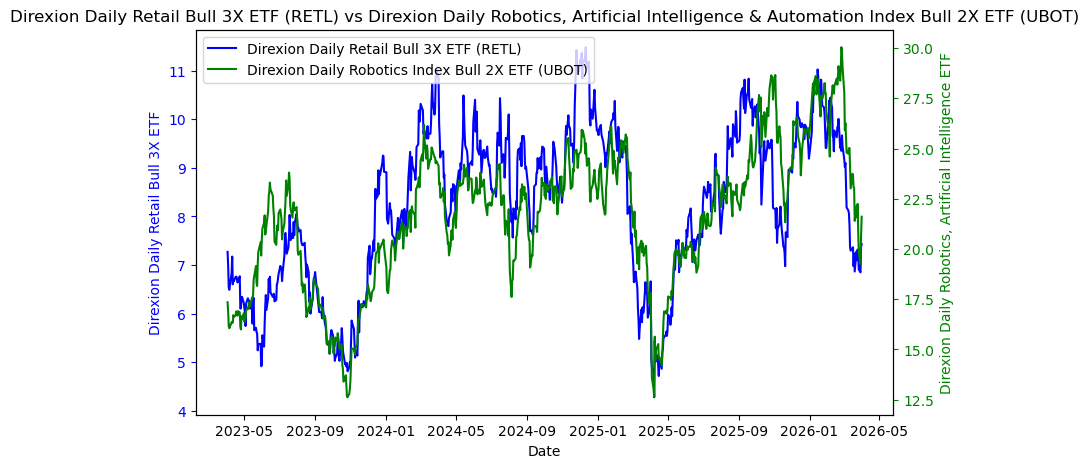

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(dataMR.index, dataMR["RETL" ], color='b',label="Direxion Daily Retail Bull 3X ETF (RETL)")
ax1.set_xlabel('Date')
ax1.set_ylabel('Direxion Daily Retail Bull 3X ETF', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(dataMR.index, dataMR["UBOT" ], color='g', label="Direxion Daily Robotics Index Bull 2X ETF (UBOT)")
ax2.set_ylabel('Direxion Daily Robotics, Artificial Intelligence ETF', color='g')
ax2.tick_params('y', colors='g')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines = lines1 + lines2 
labels = labels1 + labels2 
plt.legend(lines, labels)
plt.title('Direxion Daily Retail Bull 3X ETF (RETL) vs Direxion Daily Robotics, Artificial Intelligence & Automation Index Bull 2X ETF (UBOT)')
plt.show()

Based on the graph it is a good sign the prices evolved similarly but not completely similarly because ideally, the spread should have a high variance to allow for recurring beneficial trades while reliably fluctuating around the mean. 

First we look at the linear mean reverting strategy: calculate the normalized deviation of the price from its moving average, and keep the number of units in this asset inversely proportional to this normalized deviation.

In [12]:
dataMR1pair =  pd.merge(dataMR["RETL"], dataMR["UBOT" ], on = 'Date')

def johansenTest(data, det_order):
    try:
        var = api.VAR(dataMR1pair.values)
        lags = var.select_order()
        k_ar_diff = lags.selected_orders['aic']
        result = vm.coint_johansen(data, det_order, k_ar_diff)
        print(f'Johansen Test Results (det_order={det_order})')
        print('Trace Statistics:\n',  result.lr1)
        print('Critical Values (Trace):\n', result.cvt) 
        print('Eigenvectors of the VECM coefficient matrix:\n', result.evec) 
        return  result
    except Exception as e:
        print(f'An error occurred during the Johansen test: {e}')
        return None

cointResMR =  johansenTest(dataMR1pair, det_order=0)       

Johansen Test Results (det_order=0)
Trace Statistics:
 [24.9977818   6.22593076]
Critical Values (Trace):
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Eigenvectors of the VECM coefficient matrix:
 [[ 1.05894468 -0.33711343]
 [-0.49466434 -0.14321292]]


The eigenvectors of the above Johansen test can be applied as hedge ratios for the ETFs to create a stationary portfolio. The first cointegrating vector is the appropriate because it has the shortest half-life for mean reversion. 

The construction of a mean-reverting spread is

$$ y = y_{1} - h y_{2} $$

where $y$ is the stationary time series and $h $ is the hedge ratio or the number of shares. 




In [13]:
portfolioMR=pd.DataFrame(np.dot(dataMR1pair.values, cointResMR.evec[:, 0]))
portfolioMRlag=portfolioMR.shift()
portfolioMRdelta=portfolioMR-portfolioMRlag
portfolioMR1=pd.concat([portfolioMRlag, portfolioMRdelta], axis=1)
olsResMR=sm.ols(formula="portfolioMR1.iloc[:,1] ~ portfolioMR1.iloc[:,0]", data=portfolioMR1).fit()
halflifeMR=-np.log(2)/olsResMR.params.iloc[1]
print(f"Half-life: {halflifeMR:.2f}")
lookbackMR=np.round(halflifeMR).astype(int) 

Half-life: 14.08


In the linear model the price change can be described as: 

$$ \Delta y(t) = \lambda y(t-1) + \mu + \beta t + \alpha_{1} \Delta y(t-1) + ... + \alpha_{k} \Delta y(t-k) +  \epsilon_{t} $$

If we transform it to a differntial form and omit the drift $(\beta t)$ and the lagged differences $( \Delta y(t-1), ... ,\Delta y(t-k)  )$ then it can be interpreted as the Ornstein-Uhlenbeck formula for mean-reverting process:

$$ dy(t) = ( \lambda y(t-1) + \mu )dt + d \epsilon  $$

From stohastic calculus its solution for the expected value:

$$ E (y(t)) = y_{0} exp( \lambda t ) -\mu / \lambda (1 - exp(\lambda t)) $$

$\lambda$ is negative for a mean-reverting process and if $t$ tends to infinity it is $ -\mu / \lambda $ and its half-life is $ -log(2) / \lambda $. Half-life measures how quickly a price series reverts to its mean. The main reason why half-life is calculated is to get the lookback variable which defines the length of the moving avarage and moving standard deviation. 

In [14]:
numUnitsMR =-(portfolioMR-portfolioMR.rolling(lookbackMR).mean())/portfolioMR.rolling(lookbackMR).std()
positionsMR=pd.DataFrame(np.dot(numUnitsMR.values, np.expand_dims(cointResMR.evec[:, 0], axis=1).T)*dataMR1pair)

The strategy continuously enters and exits positions: one asset is longed and another one is shorted. The share of the units is determined by the eigenvector of Johansen's test. The number of the assets can be expanded to three or even more ones as well, the cointegrating vector of Johansen's test would be good for them.  

In [15]:
pnlMR1=np.sum((positionsMR.shift().values)*(dataMR1pair.pct_change().values), axis=1) 
returnsMR1=pnlMR1/np.sum(np.abs(positionsMR.shift()), axis=1)
returnsMR1 = returnsMR1.dropna()

Now we can look at some backtesting metrics of this strategy: the annual percentage rate and the Sharpe-ratio. Sharpe-ratio measures the risk-adjusted return, if it is higher than one is considered as a good investment, while above than two is excellent. The benchmark is a buy and hold position of the ETF S&P 500 (SPY).  

The backtests in this jupyter file do not contain any transaction costs.

In [16]:
cumulativeReturnsMR1 = (np.cumprod(1+returnsMR1) ) 
APR = np.prod(1+returnsMR1)**(252/len(returnsMR1))-1
Sharpe = np.sqrt(252)*np.mean(returnsMR1)/np.std(returnsMR1)

print(f'APR={APR:.2f} Sharpe={Sharpe:.2f}')

APR=0.20 Sharpe=0.84


In [17]:
sameIDsMR1 = returnsMR1.index.intersection(dataSPY.index)
spyReturnsMR1 = dataSPY.loc[sameIDsMR1]  
spyReturnsMR1 = spyReturnsMR1.pct_change().shift(-1)

benchmarkReturnsMR1 = []
for date, row in spyReturnsMR1.iterrows():
    benchmarkReturn = spyReturnsMR1.loc[date]
    benchmarkReturnsMR1.append(benchmarkReturn)
benchmarkReturnsMR1 = pd.DataFrame(benchmarkReturnsMR1, index=returnsMR1.index)
benchmarkCumulativeReturnsMR1 = (np.cumprod(1 + benchmarkReturnsMR1) )  

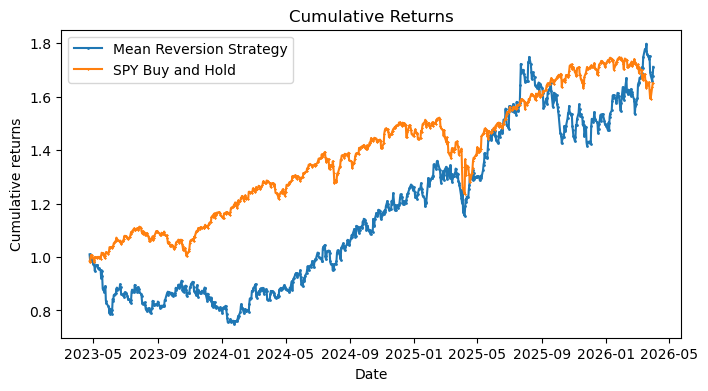

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(cumulativeReturnsMR1, label="Mean Reversion Strategy", marker="o", markersize=1)
plt.plot(benchmarkCumulativeReturnsMR1, label="SPY Buy and Hold", marker="x", markersize=1)
plt.xlabel('Date')
plt.ylabel('Cumulative returns')
plt.legend()
plt.title('Cumulative Returns')
plt.show()

The graph looks good compared to the other ETF pairs because the APR of the other pairs are around 0.03. The PairSelection algorithm can find about 3 other pairs that perform similarly well to the RETL and UBOT. These cumulative returns do not include costs and levereged ETFs have higher costs than regular ETFs. 

The main advantage of the linear mean-reverting strategy is that it does not have any data-snooping bias as the strategy has no parameters to optimize. The disadvantages of the linear mean reversion strategy are: at the beginning the maximum capital required is unknown as there is no limit to the temporary deviation of the price from its average. Moreover we cannot really enter and exit an infinitesimal number of shares whenever the price moves by an infinitesimal amount.

## <center> Pairs trading with Kalman filter </center>

The Kalman filter can be good to dynamically estimate the hedge ratio between the two assets and the evolving trading positions. It is an optimal linear algorithm that updates the expected value of a hidden variable based on the latest value of an observable variable. It is only optimal if the noises are Gaussian and it minimizes the mean square error of the estimation. The followings

$$ y (t) = x(t) \beta(t) + \epsilon(t) $$ 
$$ \beta(t) = \beta(t-1) + \omega(t-1) $$ 

are the obeservation equation and the state equation, respectively. $ y(t) $ indicates the observations, $\beta$ is the hedge ratio, and $x$ is the another asset. The Gaussian noise term is $ \epsilon(t) $ with variance $ V_{\epsilon}$ and the other Gaussian noise term is $\omega(t-1)$ with covariance  $V_{\omega}$ .

In [19]:
dataMR2pair =  pd.merge(dataMR["RETL" ], dataMR["UBOT" ], on = 'Date')

In [20]:
dataMR2pair['ratio'] = dataMR2pair.iloc[:,0] / dataMR2pair.iloc[:,1]

ratioMR2 = dataMR2pair.iloc[:,0] / dataMR2pair.iloc[:,1]

In [21]:
kf = KalmanFilter(transition_matrices = [1],
              observation_matrices = [1],
              initial_state_mean = 0,
              initial_state_covariance = 1,
              observation_covariance=1,
              transition_covariance=.0001)

meanMR2, covMR2 = kf.filter(ratioMR2.values)
meanMR2, stdMR2 = meanMR2.squeeze(), np.std(covMR2.squeeze())

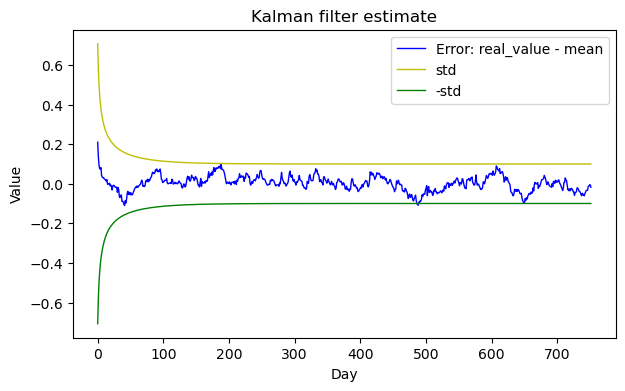

In [22]:
plt.figure(figsize=(7,4))
plt.plot(ratioMR2.values - meanMR2, 'b', lw=1)
plt.plot(np.sqrt(covMR2.squeeze()), 'y', lw=1)
plt.plot(-np.sqrt(covMR2.squeeze()), 'g', lw=1)
plt.title('Kalman filter estimate')
plt.legend(['Error: real_value - mean', 'std', '-std'])
plt.xlabel('Day')
plt.ylabel('Value')
plt.show()

From the graph it can be seen that the diversion from the mean fluctuate within the range of the +/- standard deviation from (value - mean). It is ideal for the Kalman Filter because too big diversion can detour it and when the deviation is too small it is harder to make profit.  

In [23]:
dataMR2pair['mean'] = meanMR2.squeeze()
dataMR2pair['cov'] = covMR2.squeeze()
dataMR2pair['std'] = np.sqrt(dataMR2pair['cov'])
dataMR2pair = dataMR2pair.dropna()

#this lenght of moving avarage provides better result than the lookbackMR
dataMR2pair['ma'] = dataMR2pair['ratio'].rolling(5).mean()
dataMR2pair['z_score'] = (dataMR2pair['ma'] - dataMR2pair['mean']) / dataMR2pair['std']

dataMR2pair['position_1'] = np.nan
dataMR2pair['position_2'] = np.nan

The difference between the Bollinger band method and the simple linear mean-reverting strategy is that during the Bollinger band we enter into a position only when the price deviates by more than entryZscore standard deviations from the mean and exit when the price mean-reverts to exitZscore standard deviations from the mean. 

In [24]:
for i in range(dataMR2pair.shape[0]):
    if dataMR2pair['z_score'].iloc[i] < -0.1:
        dataMR2pair.loc[dataMR2pair.index[i],'position_1'] = 1
        dataMR2pair.loc[dataMR2pair.index[i],'position_2'] = -round(dataMR2pair.loc[dataMR2pair.index[i],'ratio'], 0)
    if dataMR2pair.loc[dataMR2pair.index[i],'z_score'] > 0.1:
        dataMR2pair.loc[dataMR2pair.index[i],'position_1'] = -1
        dataMR2pair.loc[dataMR2pair.index[i],'position_2'] = round(dataMR2pair.loc[dataMR2pair.index[i],'ratio'], 0)
    if (abs(dataMR2pair.loc[dataMR2pair.index[i],'z_score']) < 0.1) & (abs(dataMR2pair.loc[dataMR2pair.index[i],'z_score']) > 0):
        dataMR2pair.loc[dataMR2pair.index[i],'position_1'] = 0
        dataMR2pair.loc[dataMR2pair.index[i],'position_2'] = 0

In [25]:
dataMR2pair['returns'] = ((dataMR2pair.iloc[:,0] - dataMR2pair.iloc[:,0].shift(1)) / dataMR2pair.iloc[:,0].shift(1)) * dataMR2pair['position_1'].shift(
    1) + ((dataMR2pair.iloc[:,1] - dataMR2pair.iloc[:,1].shift(1)) / dataMR2pair.iloc[:,1].shift(1)) * dataMR2pair['position_2'].shift(1)

cumulativeReturnsMR2 = (np.cumprod(1+dataMR2pair['returns']) )

In [26]:
APR = np.prod(1+dataMR2pair['returns'])**(252/len(dataMR2pair['returns']))-1
Sharpe = np.sqrt(252)*np.mean(dataMR2pair['returns'])/np.std(dataMR2pair['returns'])
print(f'APR={APR:.2f} Sharpe={Sharpe:.2f}')

APR=0.49 Sharpe=0.99


In [27]:
sameIDsMR2 = dataMR2pair['returns'].index.intersection(dataSPY.index)
spyReturnsMR2 = dataSPY.loc[sameIDsMR2]  
spyReturnsMR2 = spyReturnsMR2.pct_change().shift(-1)

benchmarkReturnsMR2 = []
for date, row in spyReturnsMR2.iterrows():
    benchmarkReturn = spyReturnsMR2.loc[date]
    benchmarkReturnsMR2.append(benchmarkReturn)
benchmarkReturnsMR2 = pd.DataFrame(benchmarkReturnsMR2, index=dataMR2pair['returns'].index)
benchmarkCumulativeReturnsMR2 = (np.cumprod(1 + benchmarkReturnsMR2) )  

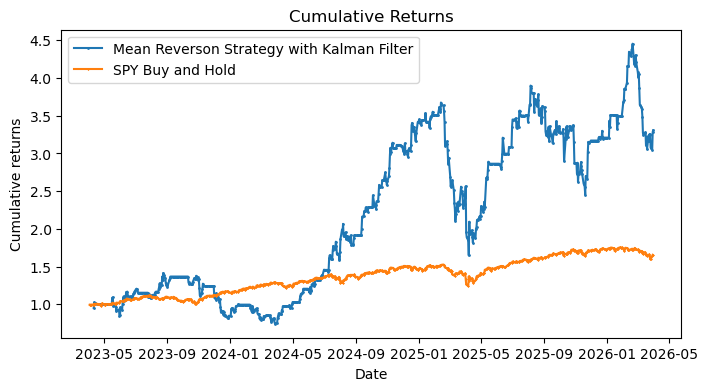

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(cumulativeReturnsMR2, label="Mean Reverson Strategy with Kalman Filter", marker="o", markersize=1)
plt.plot(benchmarkCumulativeReturnsMR2, label="SPY Buy and Hold", marker="x", markersize=1)
plt.xlabel('Date')
plt.ylabel('Cumulative returns')
plt.legend()
plt.title('Cumulative Returns')
plt.show()

## <center> Cross-sectional Momentum Strategy </center>

The momentum strategy complement the mean reversion strategy well since momentum strategy is better in trending, volatile markets, because at these times the common belief is that the strong performance will continue. Contrary to this the mean reverting strategies excel in choppy markets since they rely on the principle that some prices overreact and will eventually return to a more consensus level. 

There are two main types of momentum strategies: time series and cross-sectional. Time series momentum is about that past returns of a price series are positively correlated with future returns. Cross-sectional momentum considers the relative position of the other assets: a price series outperforming other price series will possible do this in the future as well. 

The subject of this stategy is the stocks of Nasdaq 100. The tickers of these stocks are from the Wikipedia page of Nasdaq 100.

In [29]:
import requests
from io import StringIO

url = 'https://en.wikipedia.org/wiki/Nasdaq-100'

header = {
  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
  "X-Requested-With": "XMLHttpRequest"
}

r = requests.get(url, headers=header)

dfs = pd.read_html(StringIO(r.text))

nasdaq100Tickers = dfs[4].Ticker.tolist()

In [37]:
dataM = yf.download(nasdaq100Tickers, start='2023-04-03', end='2026-04-02', auto_adjust=False)['Adj Close']
dataNDX = yf.download('NDX', start='2023-04-03', end='2026-04-02', auto_adjust=False)['Adj Close']

[*********************100%***********************]  101 of 101 completed
[*********************100%***********************]  1 of 1 completed


In [38]:
dataM = dataM.resample('ME').last()
dataNDX = dataNDX.resample('ME').last()

This algorithm selects the best and the worst 10 performing companies and put them into the long and short portfolio of stocks then calculates the returns of the combined long and short portfolio and that of the benchmark portfolio.

In [39]:
nCompanies = 10

nStocksM = len(dataM.columns)
monthlyReturnsM = dataM.pct_change(1, fill_method=None)
yearlyReturnsM = dataM.pct_change(12, fill_method=None)

momentumSignalM = (yearlyReturnsM - monthlyReturnsM).dropna()
rankedSignalM = momentumSignalM.rank(axis = 1, ascending = False)
longsM = rankedSignalM.apply(lambda x: x.index[x <= nCompanies].tolist(),axis = 1)
longsM.name = 'long'
shortsM = rankedSignalM.apply(lambda x: x.index[x  > nStocksM - nCompanies ].tolist(),axis = 1)
shortsM.name = 'short'
longShortM = pd.concat([longsM, shortsM], axis = 1)

In [40]:
monthlyfwReturnsM = dataM.pct_change(fill_method=None).shift(-1)
returnsNDX = dataNDX.pct_change().shift(-1)
longShortM = longShortM.iloc[:-1]

commonIDM = longShortM.index.intersection(monthlyfwReturnsM.index).intersection(returnsNDX.index)
longShortM = longShortM.loc[commonIDM]
monthlyfwReturnsM = monthlyfwReturnsM.loc[commonIDM]
returnsNDX = returnsNDX.loc[commonIDM]

In [41]:
portfolioReturnsM = []
benchmarkReturnsM = []

for date, row in longShortM.iterrows():
    longStocks = row["long"]
    shortStocks = row["short"]

    longReturn = monthlyfwReturnsM.loc[date, longStocks].mean()
    shortReturn = -monthlyfwReturnsM.loc[date, shortStocks].mean()

    portfolioReturn = (longReturn + shortReturn) / 2.0
    benchmarkReturn = returnsNDX.loc[date]

    portfolioReturnsM.append(portfolioReturn)
    benchmarkReturnsM.append(benchmarkReturn)

In [42]:
portfolioReturnsM = pd.DataFrame(portfolioReturnsM, index=longShortM.index)
benchmarkReturnsM = pd.DataFrame(benchmarkReturnsM, index=longShortM.index)

cumulativeReturnsM = (1 + portfolioReturnsM).cumprod().shift(1).fillna(1.0)
benchmarkCumulativeReturnsM = (1 + benchmarkReturnsM).cumprod().shift(1).fillna(1.0)

In [43]:
APR = np.prod(cumulativeReturnsM, axis=0)**(12/len(cumulativeReturnsM))-1
Sharpe = np.sqrt(12)*np.mean(cumulativeReturnsM-1)/np.std(cumulativeReturnsM-1, axis=0)
print( f"APR={APR.iloc[0]:.2f} Sharpe={Sharpe.iloc[0]:.2f}" ) 

APR=3.70 Sharpe=6.58


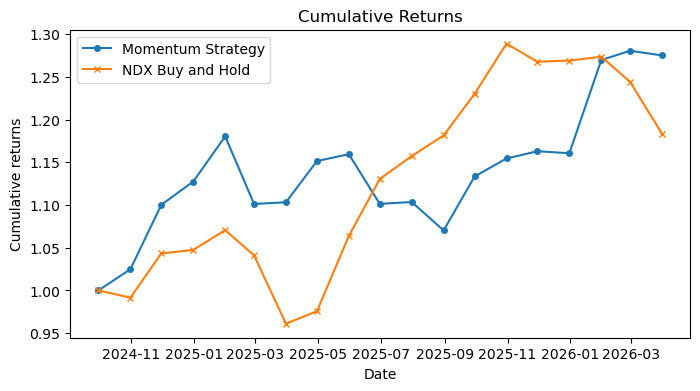

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(cumulativeReturnsM, label="Momentum Strategy", marker="o", markersize=4)
plt.plot(benchmarkCumulativeReturnsM, label="NDX Buy and Hold", marker="x", markersize=4)
plt.xlabel('Date')
plt.ylabel('Cumulative returns')
plt.legend()
plt.title('Cumulative Returns')
plt.show()

Momentum and mean-reverting algorithmic strategies can be considered as complementaries to each other because they take advantage of different market shifts. The combination of the two can generate lower overall portfolio drawdown and higher risk-adjusted returns. 

The strategy optimalization i.e. how we should allocate between the strategies is similar to portfolio optimalization. The main attributes:

* Strategy expected returns
* Strategy volatilities
* Correlation betwwen strategies

The expected returns $\mu_{1}, \mu_{2}$, the standard deviations $ \sigma_{1}, \sigma_{2} $ and the correlation $\rho$ of the two strategies: 

$$ \mu_{p} = w \mu_{1} + (1-w) \mu_{2} $$
$$ \sigma_{p} = \sqrt{ w_{1}^{2} \sigma_{1}^{2} + (1-w)^{2} w_{1}^{2} + 2w(1-w)\sigma_{1} \sigma_{2} \rho } $$
$$ SR_{p} = \frac{\mu_{p}}{\sigma_{p}} $$

Different optimalization weighting can be applied but the main problem when we want to to maximize the expected return subject to a constant variance of returns constraint or to minimize the variance of returns subject to a constant expected return constraint: forecasting from historical returns can be misleading. That's why many practioners focus on estimating the covariances of the returns. Another approach is risk parity when the expected returns are completely ignored and only the correlation and the volatilites of strategies are taken in to account.  

It is worth mentioning that backtesting results do not guarantee future performance. The demonstrated strategy results are intended solely for educational purposes and should not be considered as investment advice. 